<a href="https://colab.research.google.com/github/melany0126/Reto-1.-Matem-tica-III-Grupo-D/blob/main/Reto2__NOTEBOOK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Reto 02: Análisis masico de una pieza industrial**

Nombres: Melany Mera, Abigail Manguay, Uriel Changoluisa


In [21]:
# Importamos las librerías que vamos a necesitar
import numpy as np
import sympy as sp
from scipy import integrate
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [22]:
#SÍMBOLOS Y LA FUNCIÓN DE DENSIDAD
R    = 3      # radio mayor [cm]
a    = 1      # radio menor [cm]
rho0 = 7.8   # densidad base del acero [g/cm³]
k    = 0.1   # factor de variación axial [cm⁻²]

# Variables simbólicas
r = sp.Symbol('r', positive=True)
z = sp.Symbol('z')

# Densidad: mayor en el ecuador (z=0), menor en los polos (z=±a)
# aquí el laminado comprime más la zona central del tubo
rho_sym = rho0 * (1 + k * z**2)

print("Función de densidad:")
display(rho_sym)

Función de densidad:


0.78*z**2 + 7.8

In [23]:
#MASA TOTAL
lim_z = sp.sqrt(a**2 - (r - R)**2)   # límite de z: semicírculo

# Mostramos la integral completa antes de resolverla
I_masa = sp.Integral(
    rho_sym * r,
    (z, -lim_z, lim_z),
    (r, R-a, R+a)
)
display(I_masa)

# Resolvemos paso a paso
paso1 = sp.integrate(rho_sym * r, (z, -lim_z, lim_z))       # integral en z
paso2 = sp.integrate(sp.expand(paso1), (r, R-a, R+a))        # integral en r
masa  = 2 * sp.pi * paso2                                     # integral en theta

print("Resultado:")
display(sp.simplify(masa))
print(f"m = {float(masa):.4f} g")

Integral(r*(0.78*z**2 + 7.8), (z, -sqrt(1 - (r - 3)**2), sqrt(1 - (r - 3)**2)), (r, 2, 4))

Resultado:


47.97*pi**2

m = 473.4449 g


In [24]:
#CENTRO DE MASA
# Mostramos la integral de Mz
I_Mz = sp.Integral(
    z * rho_sym * r,
    (z, -lim_z, lim_z),
    (r, R-a, R+a)
)
display(I_Mz)

# Resolvemos
paso1_z = sp.integrate(z * rho_sym * r, (z, -lim_z, lim_z))
paso2_z = sp.integrate(sp.expand(paso1_z), (r, R-a, R+a))
Mz      = 2 * sp.pi * paso2_z

print("Mz =")
display(sp.simplify(Mz))

print("z_barra = Mz / m =")
display(sp.simplify(Mz / masa))

print()
print("Centro de masa = (0, 0, 0)")
print("El toro es simétrico respecto a z=0 → el CM está en el origen.")

Integral(r*z*(0.78*z**2 + 7.8), (z, -sqrt(1 - (r - 3)**2), sqrt(1 - (r - 3)**2)), (r, 2, 4))

Mz =


0

z_barra = Mz / m =


0


Centro de masa = (0, 0, 0)
El toro es simétrico respecto a z=0 → el CM está en el origen.


In [25]:
# MOMENTOS DE INERCIA
# En esta parte calculamos el momento de inercia respecto al eje Z.

I_Iz = sp.Integral(
    r**2 * rho_sym * r,
    (z, -lim_z, lim_z),
    (r, R-a, R+a)
)
# Aquí mostramos la integral que vamos a resolver.
print("Integral para Iz:")
display(I_Iz)
# Primero resolvemos la integral en la dirección z.
paso1_Iz = sp.integrate(r**2 * rho_sym * r, (z, -lim_z, lim_z))
# Luego resolvemos la integral con respecto al radio r.
paso2_Iz = sp.integrate(sp.expand(paso1_Iz), (r, R-a, R+a))
# Multiplicamos por 2π para completar el cálculo del momento de inercia.
Iz = 2 * sp.pi * paso2_Iz
# Finalmente mostramos el resultado simplificado y el valor de Iz.
print("Iz =")
display(sp.simplify(Iz))
print(f"Iz = {float(Iz):.4f} g·cm²")

Integral para Iz:


Integral(r**3*(0.78*z**2 + 7.8), (z, -sqrt(1 - (r - 3)**2), sqrt(1 - (r - 3)**2)), (r, 2, 4))

Iz =


467.415*pi**2

Iz = 4613.2011 g·cm²


In [26]:
# MOMENTOS DE INERCIA EN X
# En esta parte calculamos el momento de inercia respecto al eje X.
# Se usa la fórmula con y² + z².

I_Ix = sp.Integral(
    r**2 * rho_sym * r + z**2 * rho_sym * r,
    (z, -lim_z, lim_z),
    (r, R-a, R+a)
)
# Aquí mostramos la integral antes de resolverla.
print("Integral para Ix (y²+z²)·ρ·r, antes de integrar en theta):")
display(I_Ix)

# Primero calculamos la parte que viene de r² relacionada con y².
paso1_r = sp.integrate(r**2 * rho_sym * r, (z, -lim_z, lim_z))

# Después calculamos la parte que corresponde a z².
paso1_z2 = sp.integrate(z**2 * rho_sym * r, (z, -lim_z, lim_z))

# Se multiplica cada parte por su factor correspondiente de la integral angular
# y se suman para obtener el momento de inercia en X.
Ix_r = sp.pi * sp.integrate(sp.expand(paso1_r), (r, R-a, R+a))
Ix_z = 2*sp.pi * sp.integrate(sp.expand(paso1_z2), (r, R-a, R+a))
Ix = sp.simplify(Ix_r + Ix_z)

# se muestra el resultado simplificado y el valor numérico.
print("Ix =")
display(Ix)
print(f"Ix = {float(Ix):.4f} g·cm²")

Integral para Ix (y²+z²)·ρ·r, antes de integrar en theta):


Integral(r**3*(0.78*z**2 + 7.8) + r*z**2*(0.78*z**2 + 7.8), (z, -sqrt(1 - (r - 3)**2), sqrt(1 - (r - 3)**2)), (r, 2, 4))

Ix =


245.9925*pi**2

Ix = 2427.8487 g·cm²


In [30]:
# VERIFICACIÓN NUMÉRICA CON SCIPY
# Datos del problema
R = 3
a = 1
rho0 = 7.8
k = 0.1

# Límites de integración
def z_inf(r):
    return -np.sqrt(a**2 - (r - R)**2)
def z_sup(r):
    return np.sqrt(a**2 - (r - R)**2)

# Masa
def masa(z, r):
    return rho0 * (1 + k*z**2) * r
resultado_masa, _ = integrate.dblquad(masa, 2, 4, z_inf, z_sup)
masa_num = 2*np.pi*resultado_masa
masa_analitica = 473.4449
error_masa = abs(masa_num - masa_analitica)/masa_analitica*100
print("Masa numérica:", round(masa_num,4), "g")
print("Error masa:", error_masa,"%")

# Centro de masa (z)
def momento_z(z, r):
    return rho0*(1+k*z**2)*r*z
resultado_Mz, _ = integrate.dblquad(momento_z, 2, 4, z_inf, z_sup)
z_barra = 2*np.pi*resultado_Mz/masa_num
print("z barra =", z_barra)

# Momento de inercia Iz
def inercia_z(z, r):
    return rho0*(1+k*z**2)*r**3
resultado_Iz, _ = integrate.dblquad(inercia_z, 2, 4, z_inf, z_sup)
Iz_num = 2*np.pi*resultado_Iz
Iz_analitico = 4613.2011
error_Iz = abs(Iz_num-Iz_analitico)/Iz_analitico*100

print("Iz =", round(Iz_num,4))
print("Error Iz:", error_Iz,"%")

Masa numérica: 473.4449 g
Error masa: 4.883410495226778e-06 %
z barra = 0.0
Iz = 4613.2011
Error Iz: 8.916828480746951e-07 %


In [28]:
#EXPERIMENTO DE SENSIBILIDAD
# Parámetros
R = 3.0
a = 1.0
rho0 = 7.8
k = 0.1

# Límites
def z_low(r):
    return -np.sqrt(a**2-(r-R)**2)

def z_high(r):
    return np.sqrt(a**2-(r-R)**2)

# Nueva densidad
# Se aumenta un 20 % cuando r>3
def rho_mod(z,r):

    rho = rho0*(1+k*z**2)

    if r>3:
        return 1.2*rho
    else:
        return rho

# Masa
def f_masa(z,r):
    return rho_mod(z,r)*r
masa_dbl,_=integrate.dblquad(f_masa,2,4,z_low,z_high)
masa=2*np.pi*masa_dbl

# Momento respecto a z
def f_Iz(z,r):
    return rho_mod(z,r)*r**3
Iz_dbl,_=integrate.dblquad(f_Iz,2,4,z_low,z_high)
Iz=2*np.pi*Iz_dbl

# Momento respecto al eje z
# (para centro de masa)
def f_Mz(z,r):
    return rho_mod(z,r)*z*r
Mz_dbl,_=integrate.dblquad(f_Mz,2,4,z_low,z_high)
Mz=2*np.pi*Mz_dbl
z_barra=Mz/masa

# Resultados
print("Masa:",round(masa,2),"g")
print("Iz:",round(Iz,2),"g·cm²")
print("Centro de masa:",z_barra)

Masa: 527.45 g
Iz: 5257.13 g·cm²
Centro de masa: 0.0


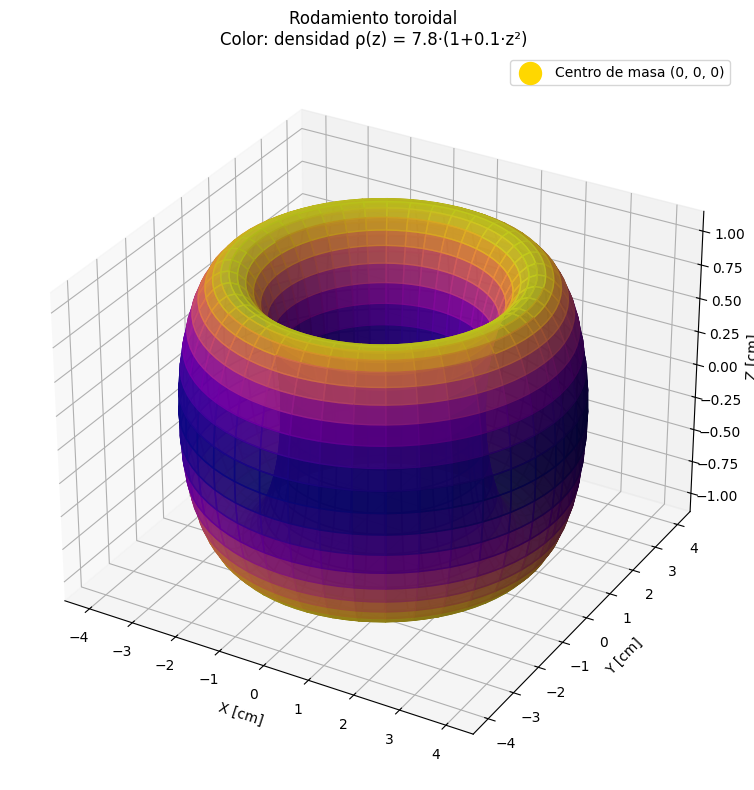

In [29]:
# VISUALIZACIÓN 3D
# Aquí se crea la figura en 3 dimensiones para observar el objeto.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Se generan los ángulos que se usan para formar la superficie del toro.
theta_v = np.linspace(0, 2*np.pi, 80)
phi_v   = np.linspace(0, 2*np.pi, 40)
T, P    = np.meshgrid(theta_v, phi_v)

# Se calculan las coordenadas X, Y y Z de cada punto del objeto.
X = (R + a*np.cos(P)) * np.cos(T)
Y = (R + a*np.cos(P)) * np.sin(T)
Z = a * np.sin(P)

# Se calcula la densidad en cada punto según la altura z.
color_val = rho0 * (1 + k * Z**2)

# Se ajustan los valores de densidad para poder representarlos con colores.
norm_val = (color_val - color_val.min()) / (color_val.max() - color_val.min())

# Se dibuja la superficie del toro con colores dependiendo de la densidad.
ax.plot_surface(X, Y, Z, facecolors=plt.cm.plasma(norm_val), alpha=0.88)

# Se marca el centro de masa del objeto.
ax.scatter([0], [0], [0], color='gold', s=250, zorder=10,
           label='Centro de masa (0, 0, 0)')

# Se colocan los nombres de los ejes y el título de la gráfica.
ax.set_xlabel('X [cm]')
ax.set_ylabel('Y [cm]')
ax.set_zlabel('Z [cm]')
ax.set_title('Rodamiento toroidal\nColor: densidad ρ(z) = 7.8·(1+0.1·z²)')
# Se muestra la leyenda, se guarda la imagen y se presenta la gráfica.
ax.legend()
plt.tight_layout()
plt.savefig('toro_3d.png', dpi=180, bbox_inches='tight')
plt.show()

#Ruliman 1.0

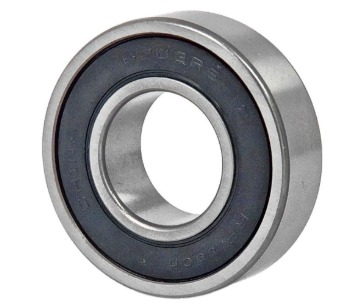

#Ruliman 1.1

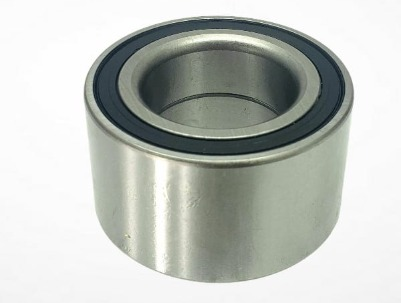